# SI 313 WN26: Experiment Module Assignment
##### Nick Pisarczyk - Wednesday, 04/15/26<br>uniqname: npisar<br> 
---

### Overview
You will design a complete experiment to test a change to a digital interface — the kind of work UX researchers and product teams do routinely at companies like Google, Meta, and Spotify. Unlike Kramer et al.'s (2014) Facebook study, which ran on nearly 700,000 users without their knowledge, you'll think carefully about how to run an ethical, well-powered experiment from scratch.

You won't collect real data. You'll design the experiment, simulate a small dataset, and analyze it. The goal is to practice the full arc of running an experiment: from research questions to results and ethical reflection.

---

### Part 1 and 2:
https://docs.google.com/document/d/1_KOzLOg2RINzoEVlHytHmUP2zquM1b0tuDhP5UoPwbc/edit?usp=sharing

---

### Part 3: Simulate and Analyze Data
In Python, simulate a realistic dataset for your experiment and run the appropriate statistical test. Include your code and outputs in a Jupyter Notebook file (.ipynb). Include your write-up with visualizations in the PDF file.

Required steps:
- Simulate 200 participants (100 per condition) with plausible outcome values for your context. Set a random seed for reproducibility.
- Create a visualization comparing the two conditions for each outcome variable.
- Run an independent sample t-test for each outcome variable.
- Report and interpret: the test statistic, p-value, and Cohen's d effect size.
- In 2–3 sentences, distinguish between statistical significance and practical importance for your results. Would an effect of this size matter in the real world?

---

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Randomization / Sample Simulation

In [27]:
# Random seed
np.random.seed(16202)

# Create the groups
group_size = 100
n = 2 * group_size
assignments = 8

students = pd.DataFrame({
    "student_id": np.arange(2*group_size),
    "condition": ["control"] * group_size + ["reminder"] * group_size
})

condition = np.array(["control"] * group_size + ["reminder"] * group_size)
df_long = students.loc[students.index.repeat(assignments)].copy()
df_long["assignment_id"] = df_long.groupby("student_id").cumcount()





"""
Simulate assignment turn-in outcomes

### Assumptions:
- Each student has 8 eligible assignments during the experiment window.
    - Therefore there can be 0 to 8 on-time submissions

Control: ~70% of assignments submitted on-time
Treatment: ~80% of assignments submitted on-time
"""
control_rate = 0.70
reminder_rate = 0.80

p = np.where(df_long["condition"].values == "control", control_rate, reminder_rate)
df_long["on_time"] = np.random.binomial(1, p, size=len(df_long))






"""
Simulate average "Time-distance" for all eight assignments, per student (hours before the deadline when first engagement happens)

### Assumptions
- Many students engage late; reminders might help make them engage earlier.
- Some students never engage, resulting in the default value of time_distance = 0.
- Otherwise, engagement time follows a right-skewed distribution
    - Lognormal: lower bound of zero, and long tail to right.
        - Most students don't start assignments super early, so right skew makes sense here
        - Don't want any negative values -- that would mean they started before the assignment was posted
    - Capped at 168 hours (7 days) to avoid crazy outliers


### Details
- Student x assignment level (df_long: one row per assignment, per student).
- For each row, set specific parameters:
    - never_p: probability student never engages with assignment (time_distance = 0)
    - mu, sigma: lognormal parameters for when student does engage
- Get a random number x for each row:
    - If x < never_p, they never engaged. Time distance = 0
    - Otherwise, get a random time_distance, using Lognormal(mean=mu, sigma=sigma)
- All simulated time_distance values capped at 168 hours (7 days) to avoid huge outliers.


### Lognormal params:
- Median is e^μ - so:
    - control_mu = 2.3 = e^2.3 = ~10h
    - reminder_mu = 2.8 = e^2.8 = ~16.4h
- Sigma is the spread
    - With μ = 2.8, σ = 0.85:
        - Lower “one-sigma” bound: e^(2.8 - 0.85)  =  e^1.95  =  ~7.0h  
        - Upper “one-sigma” bound: e^(2.8 + 0.85)  =  e^3.65  =  ~38.5h
Never Engage Groups
- Control: more of "never engage" group + later overall engagement
- Reminder: fewer of "never engage" group + earlier overall engagement
"""
never_engage_control, never_engage_reminder = 0.18, 0.10
control_mu, control_sigma = 2.3, 0.8
reminder_mu, reminder_sigma = 2.8, 0.85

never_p = np.where(df_long["condition"].values == "control", never_engage_control, never_engage_reminder)
mu = np.where(df_long["condition"].values == "control", control_mu, reminder_mu)
sigma = np.where(df_long["condition"].values == "control", control_sigma, reminder_sigma)

x = np.random.rand(len(df_long))
time_distance = np.zeros(len(df_long))

engage_mask = x >= never_p
time_distance[engage_mask] = np.random.lognormal(mean=mu[engage_mask], sigma=sigma[engage_mask])
time_distance = np.minimum(time_distance, 168)  # cap at 7 days

df_long["time_distance_hours"] = time_distance
# print(f"df_long {df_long}")





"""
### Aggregate the data

Each student's data (based on their student id) is aggregated:
- sum of all on-time assignments
- mean of all time distance values
"""
df = (df_long
      .groupby(["student_id", "condition"], as_index=False)
      .agg(on_time_count=("on_time", "sum"),
           avg_time_distance_hours=("time_distance_hours", "mean"))
     )





# Output
print(f"Data Head:\n{df.head(20)}")
print(f"\n")
df.groupby("condition")[["on_time_count","avg_time_distance_hours"]].describe()

Data Head:
    student_id condition  on_time_count  avg_time_distance_hours
0            0   control              7                 6.993091
1            1   control              5                 6.399953
2            2   control              6                 9.343709
3            3   control              5                15.137199
4            4   control              4                 3.944135
5            5   control              6                17.672341
6            6   control              6                12.749696
7            7   control              5                11.110038
8            8   control              8                 8.150800
9            9   control              8                10.747626
10          10   control              6                12.251781
11          11   control              4                 8.882546
12          12   control              3                11.013464
13          13   control              7                 9.786173
14          14

on_time_count                                           \
                  count  mean       std  min  25%  50%  75%  max   
condition                                                          
control           100.0  5.53  1.374038  2.0  5.0  6.0  6.0  8.0   
reminder          100.0  6.38  1.117175  3.0  6.0  6.0  7.0  8.0   

          avg_time_distance_hours                                           \
                            count      mean       std       min        25%   
condition                                                                    
control                     100.0  10.91688  4.290356  1.834523   7.634119   
reminder                    100.0  21.81403  9.124577  5.890878  15.655100   

                                            
                 50%        75%        max  
condition                                   
control    10.934417  13.556642  26.627783  
reminder   19.985285  28.534464  44.573261

---

## Visualizations

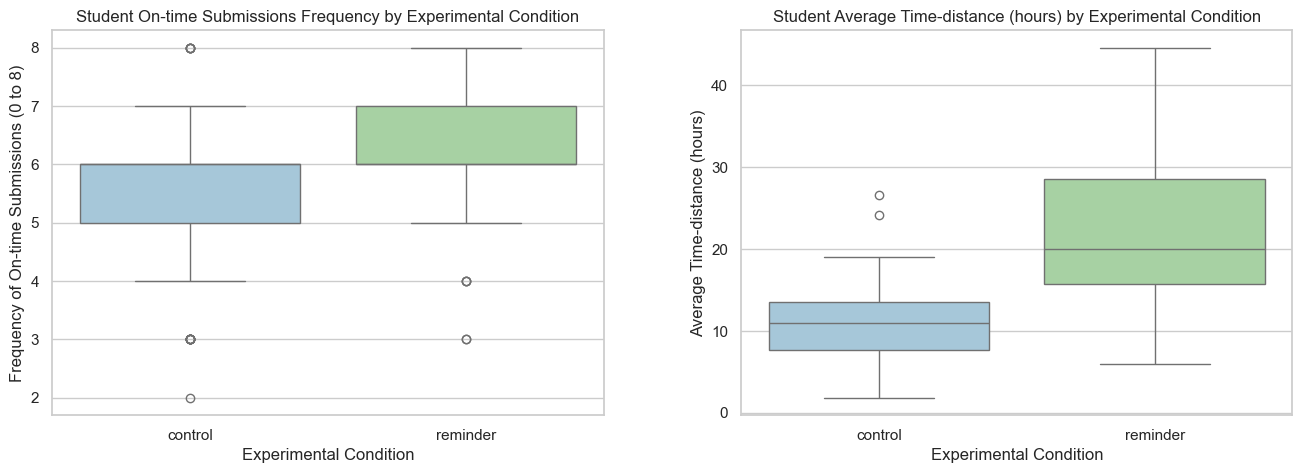

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# On-time submission count (0-8)
sns.boxplot(data=df, x="condition", y="on_time_count", ax=axes[0], hue="condition", legend=False, palette=["#9ecae1","#a1d99b"])
axes[0].set_title("Student On-time Submissions Frequency by Experimental Condition")
axes[0].set_xlabel("Experimental Condition")
axes[0].set_ylabel("Frequency of On-time Submissions (0 to 8)")

# Average Time-distance (hours)
sns.boxplot(data=df, x="condition", y="avg_time_distance_hours", ax=axes[1], hue="condition", legend=False, palette=["#9ecae1","#a1d99b"])
axes[1].set_title("Student Average Time-distance (hours) by Experimental Condition")
axes[1].set_xlabel("Experimental Condition")
axes[1].set_ylabel("Average Time-distance (hours)")

plt.subplots_adjust(wspace = 0.25)
plt.show()